Test accuracy: 0.8764


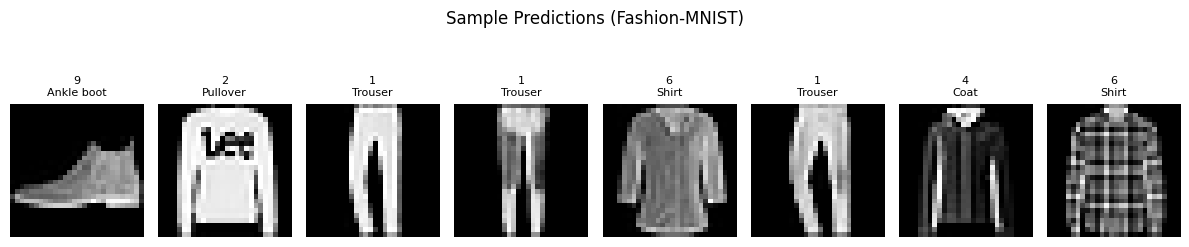

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Class names for reference
labels_list = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Build model
fashion_net = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile model
fashion_net.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
fashion_net.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.1,
    verbose=0
)

# Evaluate performance
test_loss, test_accuracy = fashion_net.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")

# Predict a few samples
sample_data = test_images[:8]
prediction_scores = fashion_net.predict(sample_data, verbose=0)
predicted_classes = np.argmax(prediction_scores, axis=1)

# Display predictions
plt.figure(figsize=(12, 3))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(sample_data[i], cmap="gray")
    plt.title(f"{predicted_classes[i]}\n{labels_list[predicted_classes[i]]}", fontsize=8)
    plt.axis("off")

plt.suptitle("Sample Predictions (Fashion-MNIST)")
plt.tight_layout()
plt.show()